In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from math import sqrt

pd.set_option('display.max_columns', None)

# Importing both CSV files and Defining them as DataFrames

online = pd.read_csv('online_sales.csv')
inperson = pd.read_csv('inperson_sales.csv')

In [2]:
# Feature Engineering a new "Order Value" column to Better Measure the Performance of Particular Products
online['Order Value'] = (online['Product Price'] * online['Quantity Sold']).round(2)
inperson['Order Value'] = (inperson['Price'] * inperson['Quantity Sold']).round(2)

### (Brief) EDA

In [3]:
inperson.groupby("Product Name")["Order Value"].agg("sum").sort_values(ascending = False).head(10)

,Order Value
Product Name,
Riddell Power JPK+ All Purpose,337668.01
Riddell Power JPK+ Skilled,332409.58
Douglas Commando,329151.81
Riddell Victor-i Youth Helmets,326923.31
Riddell Pursuit Youth,317331.99
Xenith Flyte 2 Youth TD,314295.60
Riddell Victor-i Youth Helmets Painted,310592.71
Riddell Rival JV,310506.71
Riddell Surge Youth,307158.72


In [4]:
online.groupby("Product")["Order Value"].agg("sum").sort_values(ascending = False).head(10)

,Order Value
Product,
Douglas Commando,306920.99
Xenith Velocity 2 Youth TD,298365.78
Riddell Surge Youth,297074.30
Riddell Pursuit Youth,279773.79
All Star GDK5.3YDLP 5-Pocket: 3-Pad Integrated Girdle Youth,279633.15
Nike Pro HyperStrong 3/4-Length Tights,278971.39
Xenith Flyte 2 Youth TD,278124.19
Riddell Rival JV,277915.79
Shock Doctor 3+2 Impact Short Youth (529),276213.08


In [12]:
# Descriptive Stats - will do
print(f"""Descriptive Statistics for all In-Person Sales:
{inperson.describe().round(2)}""")

print("")

print(f"""Descriptive Statistics for all Online Sales:
{online.describe().round(2)}""")

Descriptive Statistics for all In-Person Sales:
           Price  Quantity Sold  Amount Sold  Cost Amount       Year  \
count  501000.00      501000.00    501000.00    501000.00  501000.00   
mean       39.63           5.50       182.63        72.48    2022.53   
std        32.19           2.87       149.80        57.59       0.54   
min         1.99           1.00         2.05         0.80    2022.00   
25%        15.85           3.00        66.32        26.56    2022.00   
50%        39.63           6.00       182.63        72.48    2023.00   
75%        46.78           8.00       219.16        89.04    2023.00   
max       198.32          10.00       821.55       282.40    2024.00   

          Month        Day  Revenue-to-Cost Ratio  Order Value  
count  501000.0  501000.00              501000.00    501000.00  
mean        6.4      15.54                   2.72       200.01  
std         3.5       8.78                   1.25       160.83  
min         1.0       1.00                 

### Visualizations to Identify Trends & Distributions of Data

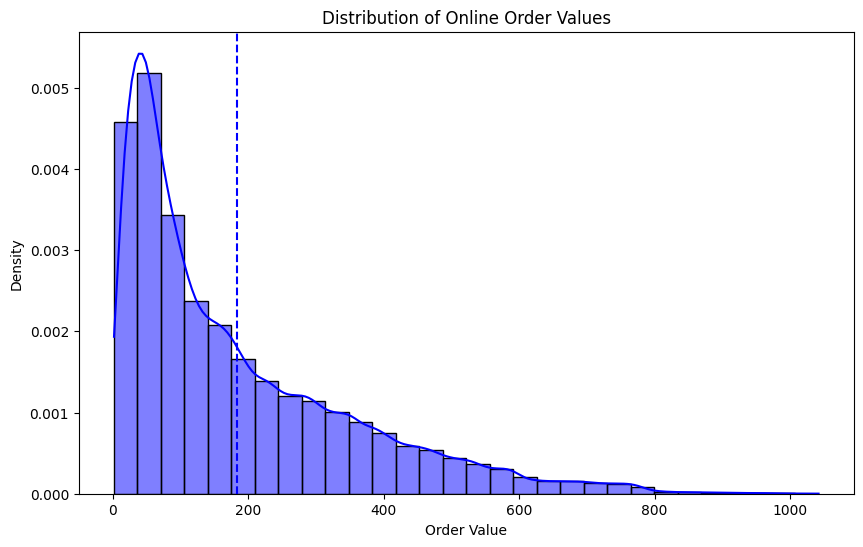

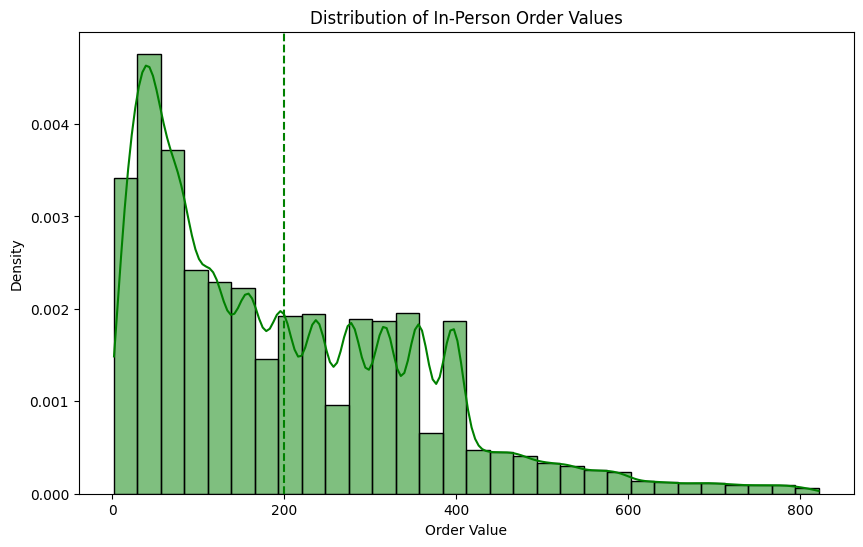

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(online['Order Value'], color = 'blue', label = 'Online', kde = True, stat = "density", bins = 30)
plt.axvline(online['Order Value'].mean(), color='blue', linestyle='--')
plt.title('Distribution of Online Order Values')
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(inperson['Order Value'], color = 'green', label = 'In-Person', kde = True, stat = "density", bins = 30)
plt.axvline(inperson['Order Value'].mean(), color='green', linestyle='--')
plt.title('Distribution of In-Person Order Values')
plt.show()

# **A/B Testing:**

## The Business Question:
Should they invest more in Online vs In-Person sales?

**Hypotheses (A/B Test)**:

We are comparing average *Order Value* (Price * Quantity Sold) between Online and In-Person sales.

**Null Hypothesis (H₀):**
There is no difference in Average Order Value (*μ*) between Online and In-Person sales.
*   Mathematically:
μ₁ = μ₂

A**lternative Hypothesis (H₁):**
There is a difference in Average Order Value (*μ*) between the two Sales channels.
*   Mathematically:
μ₁ ≠ μ₂

Also, this is a two-tailed test, since I'm not specifying which one is greater.

*   **Two-Tailed test:** Used when checking for any Difference; not a specific direction.
*   **One-Tailed test:** Used when we have a clear expectation or business decision already.

In [14]:
# Semi-Final step: T-test Computation

import numpy as np
from scipy.stats import t

# Extracting values
x1 = online['Order Value']
x2 = inperson['Order Value']

# Sample sizes
n1 = len(x1)
n2 = len(x2)

# Sample Means
mean1 = np.mean(x1)
mean2 = np.mean(x2)

# Sample variances (Unbiased)
var1 = np.var(x1, ddof = 1) # "ddof" = Delta Degrees of Freedom - set to 1 to get an Unbiased estimate of the Samples' Variance
var2 = np.var(x2, ddof = 1)

# Welch’s T-statistic
t_stat = (mean1 - mean2) / np.sqrt(var1/n1 + var2/n2)

# Degrees of freedom (Welch–Satterthwaite equation)
# This adjusts for *unequal variances and sample sizes* between the two groups.
# It estimates an "effective" degrees of freedom to use with the t-distribution.
df = (var1/n1 + var2/n2)**2 / ((var1**2)/(n1**2 * (n1 - 1)) + (var2**2)/(n2**2 * (n2 - 1)))

# Two-tailed p-value - The Probability of seeing an Extreme t-statistic; a value in the Tails of the Distribution; under the Null Hypothesis
p_val = 2 * (1 - t.cdf(abs(t_stat), df))

# Display
print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df:.2f}")
print(f"Probability of seeing a t-stat this extreme under H₀; P-value: {p_val:.4f}")

# = 0.0000; means the A/B Test showed a Statistically Significant difference between Online and In-Person "Order Value"s

T-statistic: -48.0173
Degrees of Freedom: 872932.40
Probability of seeing a t-stat this extreme under H₀; P-value: 0.0000


In [15]:
# Conclusion
if p_val < 0.05:
    print("✅ There is a statistically significant difference in order values between the two channels.")
else:
    print("❌ No statistically significant difference was found.")

✅ There is a statistically significant difference in order values between the two channels.


In [17]:
# Calculating Average Order Values for each Channel
avg_orderv_online = online['Order Value'].mean().round(2)
avg_orderv_inperson = inperson['Order Value'].mean().round(2)

# Overall Average Order Value (Aggregating both)
overall_avg = ((avg_orderv_online + avg_orderv_inperson) / 2).round(2)

# Calculating the Percentage Difference between them (using the Neutral Baseline of "Overall Average Order Value")
perc_diff = ((avg_orderv_online - avg_orderv_inperson) / overall_avg)*100

# Result
print(f"The Percentage Difference between Online and In-Person Order Values is:")
print(f"{perc_diff:.2f}%")

The Percentage Difference between Online and In-Person Order Values is:
-8.70%


The Percentage Difference of -8.7% suggests that, on average, ***in-person sales have a 8.7% higher Order Value than online sales***.

This could be due to several factors like:
*   **The Trip & The Connection:** In-Person customers might be more inclined to Purchase Premium items or Bundles as well as deals offered exclusively in stores. Possibly because it takes more effort to get to the store, people many times want to sort-of 'validate' their trip to the store by spending more
*   **The In-Store Environment:** In the store, a person can also truly *feel* the Quality of more luxurious items, etc., and fall victim to better persuasive sales techniques and impulse purchases.

## Suggestions:
*   Consider adding Exclusive Online deals/promotions to incentivize Purchases.
*   Invest in improving e-commerce through improving the interface and features of the stores' websites, user experience, and product designing and branding.
*   Regularly track performance metrics for both channels and adjust marketing strategies accordingly. Also, simultaneously, keep experimenting with various approaches and analyzing the results in order to continually try to optimize Online sales as well.